In [2]:
# 批量读取 + 单图叠加显示（Jupyter）
# 路径根目录
%matplotlib inline


import os, re
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed

# ============== 解析与读取 ==============
@dataclass
class ParsedFilename:
    sat1: str
    sat2: str
    metric: str
    ext: str

FNAME_RE = re.compile(
    r'^(?P<sat1>[A-Za-z]+_\d+_\d+)_(?P<sat2>[A-Za-z]+_\d+_\d+)_(?P<metric>[^.]+)\.(?P<ext>[^.]+)$'
)

def parse_filename(path: str) -> ParsedFilename:
    base = os.path.basename(path)
    m = FNAME_RE.match(base)
    if not m:
        # 兜底：无法解析的文件名，填充占位
        return ParsedFilename(base, base, "unknown", os.path.splitext(base)[1].lstrip("."))
    return ParsedFilename(
        sat1=m.group("sat1"),
        sat2=m.group("sat2"),
        metric=m.group("metric").lower(),
        ext=m.group("ext")
    )

def _open_text(path: str):
    # 兼容 Windows 文本编码
    try:
        return open(path, "r", encoding="utf-8")
    except UnicodeDecodeError:
        return open(path, "r", encoding="gbk", errors="ignore")

def read_time_series_fast(path: str) -> Tuple[pd.DataFrame, str]:
    """
    提速版读取：
      - 一次性读取文件，批量 rsplit 到“时间串”和“数值”
      - 向量化 to_datetime / np.fromiter 转 float
    表头示例: 'Time\\tAngleRate'
    数据示例: '24 Feb 2012 18:00:00.000000000\\t-0.0123'
    """
    with _open_text(path) as f:
        header = f.readline().strip()
        # 值列名来自表头最后一个 token；缺省为 'value'
        value_col = header.split()[-1] if header else "value"
        lines = f.read().splitlines()

    # 过滤空行，并从右侧切一次，避免时间里空格
    rec = [ln.rsplit(None, 1) for ln in lines if ln.strip()]
    if not rec:
        raise ValueError(f"No data in file: {path}")

    t_list = [r[0] for r in rec]
    # 使用 numpy 加速转浮点
    v_arr = np.fromiter((float(r[1]) for r in rec), dtype=float, count=len(rec))

    # 向量化解析时间；dayfirst=True 兼容 '24 Feb 2012'
    t = pd.to_datetime(t_list, dayfirst=True, errors="raise")
    df = pd.DataFrame({"time": t, value_col: v_arr})
    df["t_seconds"] = (df["time"] - df["time"].iloc[0]).dt.total_seconds()
    return df, value_col

def load_one_file(path: str) -> Dict[str, Any]:
    meta = parse_filename(path)
    df, value_col = read_time_series_fast(path)
    return {
        "path": path,
        "pair": [meta.sat1, meta.sat2],
        "metric": meta.metric,
        "value_name": value_col,
        "df": df
    }

# ============== 扫描文件 ==============
def list_txt_files(root: str) -> List[str]:
    files = []
    for dirpath, _, filenames in os.walk(root):
        for name in filenames:
            if name.lower().endswith(".txt"):
                files.append(os.path.join(dirpath, name))
    files.sort()
    return files




In [3]:
# 你想要的顺序（以 QF_01_17 为基准）
BASE = "QF_01_17"
ORDER_TARGETS = [
    "QF_02_15",  # Link1
    "QF_02_16",  # Link2
    "QF_02_17",  # Link3
    "QF_02_18",  # Link4
    "QF_02_19",  # Link5
    "QF_03_15",  # Link6
    "QF_03_16",  # Link7
    "QF_03_17",  # Link8
]
def normalize_pair(p1, p2):
    """若包含 BASE，则把 BASE 放到前面，便于匹配与打印。"""
    if p2 == BASE and p1 != BASE:
        return p2, p1
    return p1, p2

def sort_key(item):
    p1, p2 = normalize_pair(item["pair"][0], item["pair"][1])
    if p1 == BASE and p2 in ORDER_TARGETS:
        return (ORDER_TARGETS.index(p2), 0)
    return (len(ORDER_TARGETS), item["path"])


In [4]:
ROOT = r"E:\研究生\data\stk\range"
all_files = list_txt_files(ROOT)
print(f"发现 {len(all_files)} 个数据文件。")
if not all_files:
    raise FileNotFoundError(f"目录下未发现 .txt 文件: {ROOT}")

# ============== 并发读取（提速） ==============
MAX_WORKERS = min(8, (os.cpu_count() or 4))  # 适当限制线程数，避免过载
series_list: List[Dict[str, Any]] = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    fut2path = {ex.submit(load_one_file, fp): fp for fp in all_files}
    for fut in as_completed(fut2path):
        fp = fut2path[fut]
        try:
            series_list.append(fut.result())
        except Exception as e:
            print(f"[跳过] 解析失败: {fp}  —— {e}")

print(f"成功解析 {len(series_list)} 个文件。")

# ============== 绘图（单图叠加） ==============
# 可选：下采样，避免超大数据导致绘图卡顿
MAX_POINTS_PER_LINE = 20000  # 你可以按需要调整
def maybe_downsample(df: pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    if n <= MAX_POINTS_PER_LINE:
        return df
    step = int(np.ceil(n / MAX_POINTS_PER_LINE))
    return df.iloc[::step].copy()



发现 8 个数据文件。


C:\Users\yfh\AppData\Local\Temp\ipykernel_39804\31362429.py:69: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  t = pd.to_datetime(t_list, dayfirst=True, errors="raise")
C:\Users\yfh\AppData\Local\Temp\ipykernel_39804\31362429.py:69: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  t = pd.to_datetime(t_list, dayfirst=True, errors="raise")
C:\Users\yfh\AppData\Local\Temp\ipykernel_39804\31362429.py:69: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  t = pd.to_datetime(t_list, dayfirst=True, errors="raise")


成功解析 8 个文件。


C:\Users\yfh\AppData\Local\Temp\ipykernel_39804\31362429.py:69: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  t = pd.to_datetime(t_list, dayfirst=True, errors="raise")
C:\Users\yfh\AppData\Local\Temp\ipykernel_39804\31362429.py:69: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  t = pd.to_datetime(t_list, dayfirst=True, errors="raise")
C:\Users\yfh\AppData\Local\Temp\ipykernel_39804\31362429.py:69: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  t = pd.to_datetime(t_list, dayfirst=True, errors="raise")


Link1: qf-01-17-qf-02-15
Link2: qf-01-17-qf-02-16
Link3: qf-01-17-qf-02-17
Link4: qf-01-17-qf-02-18
Link5: qf-01-17-qf-02-19
Link6: qf-01-17-qf-03-15
Link7: qf-01-17-qf-03-16
Link8: qf-01-17-qf-03-17


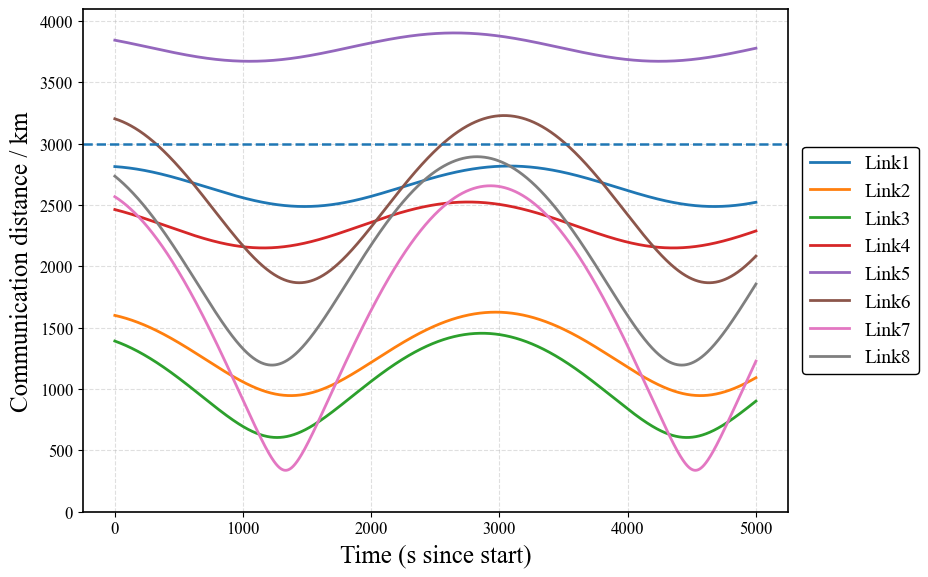

In [5]:
# === ORDER + PLOTTING ONLY (uses existing series_list) ===
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt



# 仅绘制的时间范围（秒）
MAX_T_SECONDS = 5000




# 生成新的顺序（不修改原 series_list）
ordered_series = sorted(series_list, key=sort_key)

# 控制台打印映射：Link# -> qf-xx-xx-qf-yy-yy
def pair_to_slug(p1, p2):
    p1, p2 = normalize_pair(p1, p2)
    return f"{p1.lower().replace('_','-')}-{p2.lower().replace('_','-')}"

for idx, item in enumerate(ordered_series, 1):
    print(f"Link{idx}: {pair_to_slug(item['pair'][0], item['pair'][1])}")

# —— 绘图（右侧图例 + 2900 阈值线）——
rc = {
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
}
with mpl.rc_context(rc):
    fig, ax = plt.subplots(figsize=(10, 6))

    MAX_POINTS_PER_LINE = 20000
    def maybe_downsample(df):
        n = len(df)
        if n <= MAX_POINTS_PER_LINE:
            return df
        step = int(np.ceil(n / MAX_POINTS_PER_LINE))
        return df.iloc[::step].copy()

    y_max = 0.0
    for idx, item in enumerate(ordered_series, 1):
        df = item["df"]
        if MAX_T_SECONDS is not None:
            df = df[df["t_seconds"] <= MAX_T_SECONDS]
        if df.empty:
            continue
        df = maybe_downsample(df)
        yname = item["value_name"]
        y_max = max(y_max, float(np.nanmax(df[yname].values)))
        ax.plot(df["t_seconds"], df[yname], linewidth=2.0, label=f"Link{idx}")

    ax.set_xlabel("Time (s since basicSa)")
    ax.set_ylabel("Communication distance / km")
    ax.grid(True, which="major", linestyle="--", alpha=0.4)


    THRESH_DIST = 3000  # km  距离界限

    # 只有一条距离阈值线
    ax.axhline(THRESH_DIST, linestyle="--", linewidth=1.8)
    x0, _ = ax.get_xlim()
  #  ax.text(x0, THRESH_DIST, f"  {THRESH_DIST}", va="center", ha="left")

    # 轴范围
    ax.set_ylim(bottom=0, top=max(y_max, THRESH_DIST) * 1.05)

    # # 只有一条 2900 阈值线
    # ax.axhline(2900, linestyle="--", linewidth=1.8)
    # x0, _ = ax.get_xlim()
    # ax.text(x0, 2900, "  2900", va="center", ha="left")
    #
    # # 轴范围
    # ax.set_ylim(bottom=0, top=max(y_max, 2900) * 1.05)
    # if MAX_T_SECONDS is not None:
    #     ax.set_xlim(0, MAX_T_SECONDS)


    # 图例放到右侧外部
    plt.tight_layout(rect=[0, 0, 0.82, 1])  # 右侧留白
    leg = ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=True,
        framealpha=1.0,
        ncol=1,
    )
    leg.get_frame().set_edgecolor("black")

    plt.show()


下面是方位角的内容，

-主要包括方位角的 slew rate

- 方位角的角加速度

In [15]:

ROOT = r"E:\研究生\data\stk\Azangleslewrate"
all_files = list_txt_files(ROOT)
print(f"发现 {len(all_files)} 个数据文件。")
if not all_files:
    raise FileNotFoundError(f"目录下未发现 .txt 文件: {ROOT}")

# ============== 并发读取（提速） ==============
MAX_WORKERS = min(8, (os.cpu_count() or 4))  # 适当限制线程数，避免过载
series_list: List[Dict[str, Any]] = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    fut2path = {ex.submit(load_one_file, fp): fp for fp in all_files}
    for fut in as_completed(fut2path):
        fp = fut2path[fut]
        try:
            series_list.append(fut.result())
        except Exception as e:
            print(f"[跳过] 解析失败: {fp}  —— {e}")

print(f"成功解析 {len(series_list)} 个文件。")

# ============== 绘图（单图叠加） ==============
# 可选：下采样，避免超大数据导致绘图卡顿
MAX_POINTS_PER_LINE = 20000  # 你可以按需要调整
def maybe_downsample(df: pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    if n <= MAX_POINTS_PER_LINE:
        return df
    step = int(np.ceil(n / MAX_POINTS_PER_LINE))
    return df.iloc[::step].copy()



发现 8 个数据文件。
成功解析 8 个文件。


Link1: qf-01-17-qf-02-15
Link2: qf-01-17-qf-02-16
Link3: qf-01-17-qf-02-17
Link4: qf-01-17-qf-02-18
Link5: qf-01-17-qf-02-19
Link6: qf-01-17-qf-03-15
Link7: qf-01-17-qf-03-16
Link8: qf-01-17-qf-03-17


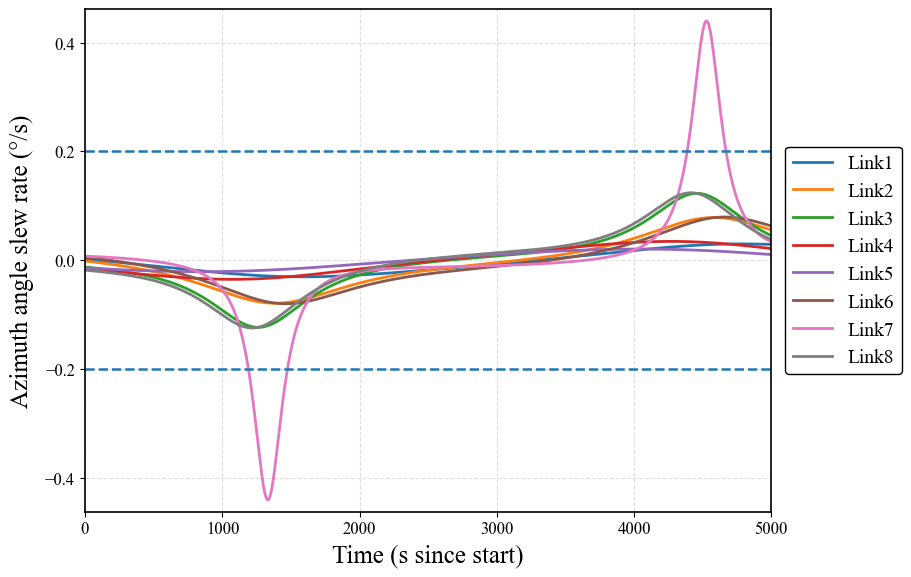

In [16]:
# === ORDER + PLOTTING ONLY (uses existing series_list) ===
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


# 仅绘制的时间范围（秒） & 阈值（上下对称）
MAX_T_SECONDS = 5000
THRESH_Y = 0.20  # °/s：Azimuth angle slew rate 界限（±THRESH_Y 都要画）


# —— 固定顺序（你已有 sort_key / ordered_series）——
ordered_series = sorted(series_list, key=sort_key)

# 给每条曲线绑定一个固定的 link_id，后面所有图都用它
def pair_to_slug(p1, p2):
    p1, p2 = normalize_pair(p1, p2)
    return f"{p1.lower().replace('_','-')}-{p2.lower().replace('_','-')}"

for i, item in enumerate(ordered_series, 1):
    item["link_id"] = f"Link{i}"

# 打印一次映射，之后不再变化
for item in ordered_series:
    p1, p2 = item["pair"]
    print(f'{item["link_id"]}: {pair_to_slug(p1, p2)}')

# —— 绘图（右侧图例 + 上下两条阈值线 ±THRESH_Y）——
rc = {
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
}
with mpl.rc_context(rc):
    fig, ax = plt.subplots(figsize=(10, 6))

    MAX_POINTS_PER_LINE = 50000
    def maybe_downsample(df):
        n = len(df)
        if n <= MAX_POINTS_PER_LINE:
            return df
        step = int(np.ceil(n / MAX_POINTS_PER_LINE))
        return df.iloc[::step].copy()

    y_max, y_min = 0.0, 0.0
    for idx, item in enumerate(ordered_series, 1):
        df = item["df"]
        if MAX_T_SECONDS is not None:
            df = df[df["t_seconds"] <= MAX_T_SECONDS]
        if df.empty:
            continue
        df = maybe_downsample(df)
        yname = item["value_name"]
        y_max = max(y_max, float(np.nanmax(df[yname].values)))
        y_min = min(y_min, float(np.nanmin(df[yname].values)))
        ax.plot(df["t_seconds"], df[yname], linewidth=2.0, label=f"Link{idx}")

    ax.set_xlabel("Time (s since basicSa)")
    ax.set_ylabel("Azimuth angle slew rate (°/s)", labelpad=8)
    ax.grid(True, which="major", linestyle="--", alpha=0.4)

    # 轴范围（y 轴对称围绕 0，覆盖数据与阈值；x 轴限 0~MAX_T_SECONDS）
    span = max(abs(y_max), abs(y_min), THRESH_Y) * 1.05
    ax.set_ylim(-span, span)
    if MAX_T_SECONDS is not None:
        ax.set_xlim(0, MAX_T_SECONDS)

    # 画上下两条阈值线，并在当前 xlim 下标注
    for yline in (+THRESH_Y, -THRESH_Y):
        ax.axhline(yline, linestyle="--", linewidth=1.8)
    x0, _ = ax.get_xlim()
    # ax.text(x0,  THRESH_Y, f"  +{THRESH_Y:.2f}", va="center", ha="left")
    # ax.text(x0, -THRESH_Y, f"  -{THRESH_Y:.2f}", va="center", ha="left")

    # 图例放到右侧外部
    plt.tight_layout(rect=[0, 0, 0.82, 1])  # 右侧留白
    leg = ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=True,
        framealpha=1.0,
        ncol=1,
    )
    leg.get_frame().set_edgecolor("black")

    plt.show()


In [17]:
# === 一阶差分：由角速度(°/s) -> 角加速度(°/s²) ===
import numpy as np

for item in ordered_series:
    df = item["df"]
    v = df[item["value_name"]].to_numpy()   # 角速度
    t = df["t_seconds"].to_numpy()          # 秒

    if len(v) < 2:
        df["accel"] = np.array([np.nan] * len(v))
        item["accel_name"] = "accel"
        continue

    dv = np.diff(v)
    dt = np.diff(t)
    # 避免极端情况下 Δt 为 0
    dt[dt == 0] = np.finfo(float).eps

    acc = dv / dt                            # 一阶差分
    acc = np.insert(acc, 0, acc[0])          # 与原长度对齐（首个用前向差分值）

    df["accel"] = acc
    item["accel_name"] = "accel"


然后我们

C:\Users\yfh\AppData\Local\Temp\ipykernel_39804\4100047723.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.74, 1])


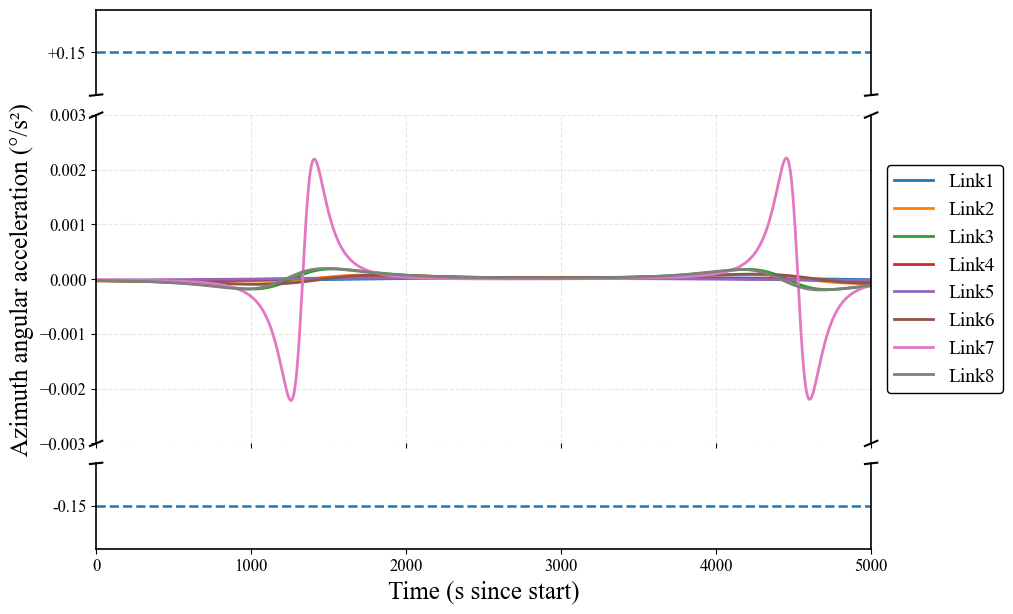

In [18]:


# —— 参数（按需改）——
MAX_T_SECONDS  = 5000      # x 轴时间窗口
THRESH_ACCEL   = 0.15      # °/s²：角加速度上下限（±THRESH_ACCEL）
SMALL_LIMIT    = 0.003     # °/s²：中间主轴细节范围的上界（对称到负侧）
THRESH_MARGIN  = 0.02      # °/s²：上/下小轴围绕阈值的留白
LEFT_PAD_RATIO = 1.10      # 主轴在数据较小时的留白比例

rc = {
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
}

with mpl.rc_context(rc):
    fig = plt.figure(figsize=(10, 7))
    gs  = fig.add_gridspec(
        nrows=3, ncols=1,
        height_ratios=[1.3, 5.0, 1.3],  # 拉开上下与中间的距离
        hspace=0.12
    )

    # 先建中轴，再让上下轴 sharex → 只在底部显示横坐标
    ax_mid = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_mid)
    ax_bot = fig.add_subplot(gs[2, 0], sharex=ax_mid)

    MAX_POINTS_PER_LINE = 20000
    def maybe_downsample(df):
        n = len(df)
        if n <= MAX_POINTS_PER_LINE:
            return df
        step = int(np.ceil(n / MAX_POINTS_PER_LINE))
        return df.iloc[::step].copy()

    # —— 仅在中轴画曲线（细节清晰）——
    y_max_abs = 0.0
    for idx, item in enumerate(ordered_series, 1):
        if "accel_name" not in item:
            continue
        df = item["df"]
        if MAX_T_SECONDS is not None:
            df = df[df["t_seconds"] <= MAX_T_SECONDS]
        if df.empty:
            continue
        df = maybe_downsample(df)
        acc = df[item["accel_name"]].to_numpy()
        y_max_abs = max(y_max_abs, float(np.nanmax(np.abs(acc))))
        ax_mid.plot(df["t_seconds"], acc, linewidth=2.0, label=f"Link{idx}")

    # —— 轴与网格 ——（上/下小轴不需要网格）
    ax_mid.grid(True, which="major", linestyle="--", alpha=0.3)
    ax_top.grid(False)
    ax_bot.grid(False)

    ax_mid.set_ylabel("Azimuth angular acceleration (°/s²)")
    ax_bot.set_xlabel("Time (s since basicSa)")

    if MAX_T_SECONDS is not None:
        ax_mid.set_xlim(0, MAX_T_SECONDS)

    # —— 中轴范围：±SMALL_LIMIT（或数据×留白，更大者）——
    span_mid = max(SMALL_LIMIT, y_max_abs * LEFT_PAD_RATIO)
    ax_mid.set_ylim(-span_mid, span_mid)

    # —— 上/下小轴：围绕 ±阈值的窄窗口，仅显示“阈值”这一条刻度标签 ——
    ax_top.set_ylim( THRESH_ACCEL - THRESH_MARGIN,  THRESH_ACCEL + THRESH_MARGIN)
    ax_bot.set_ylim(-THRESH_ACCEL - THRESH_MARGIN, -THRESH_ACCEL + THRESH_MARGIN)
    ax_top.set_yticks([ THRESH_ACCEL]); ax_top.set_yticklabels([f"+{THRESH_ACCEL:.2f}"])
    ax_bot.set_yticks([-THRESH_ACCEL]); ax_bot.set_yticklabels([f"-{THRESH_ACCEL:.2f}"])

    # 阈值虚线（只在上下小轴）
    ax_top.axhline( THRESH_ACCEL, linestyle="--", linewidth=1.8, zorder=0)
    ax_bot.axhline(-THRESH_ACCEL, linestyle="--", linewidth=1.8, zorder=0)

    # —— 断轴处理：隐藏相邻脊，并仅在底部显示横坐标 ——
    ax_top.spines["bottom"].set_visible(False)
    ax_mid.spines["top"].set_visible(False)
    ax_mid.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)

    # 只在最底部显示 x 刻度/标签，避免“横坐标重复”
    ax_top.tick_params(labelbottom=False, bottom=False)
    ax_mid.tick_params(labelbottom=False)

    # 断轴小斜线（左右各一）
    d = 0.008  # 斜线长度（轴坐标单位）
    kw = dict(color="k", clip_on=False)
    # 顶↔中
    ax_top.plot((-d, +d), (-d, +d), transform=ax_top.transAxes, **kw)
    ax_top.plot((1-d, 1+d), (-d, +d), transform=ax_top.transAxes, **kw)
    ax_mid.plot((-d, +d), (1-d, 1+d), transform=ax_mid.transAxes, **kw)
    ax_mid.plot((1-d, 1+d), (1-d, 1+d), transform=ax_mid.transAxes, **kw)
    # 中↔底
    ax_mid.plot((-d, +d), (-d, +d), transform=ax_mid.transAxes, **kw)
    ax_mid.plot((1-d, 1+d), (-d, +d), transform=ax_mid.transAxes, **kw)
    ax_bot.plot((-d, +d), (1-d, 1+d), transform=ax_bot.transAxes, **kw)
    ax_bot.plot((1-d, 1+d), (1-d, 1+d), transform=ax_bot.transAxes, **kw)

    # —— 右侧外部图例（取中轴的句柄/标签）——
    # handles, labels = ax_mid.get_legend_handles_labels()
    # fig.tight_layout(rect=[0, 0, 0.82, 1])  # 右侧留白给图例
    # leg = fig.legend(handles, labels, loc="center left",
    #                  bbox_to_anchor=(0.86, 0.5), frameon=True, framealpha=1.0, ncol=1)
    # leg.get_frame().set_edgecolor("black")

        # —— 右侧外部图例（锚在 ax_mid 外侧）——
    handles, labels = ax_mid.get_legend_handles_labels()

    # 先为右侧图例留更宽的边距（0.74 可按需要再调小/大）
    plt.tight_layout(rect=[0, 0, 0.74, 1])

    # 把图例锚在中轴坐标系外侧（x=1.02）——一定在轴外
    leg = ax_mid.legend(handles, labels,
                        loc="center left",
                        bbox_to_anchor=(1.02, 0.5),   # 轴外 2% 处
                        borderaxespad=0.0,
                        frameon=True, framealpha=1.0, ncol=1)
    leg.get_frame().set_edgecolor("black")


    plt.show()


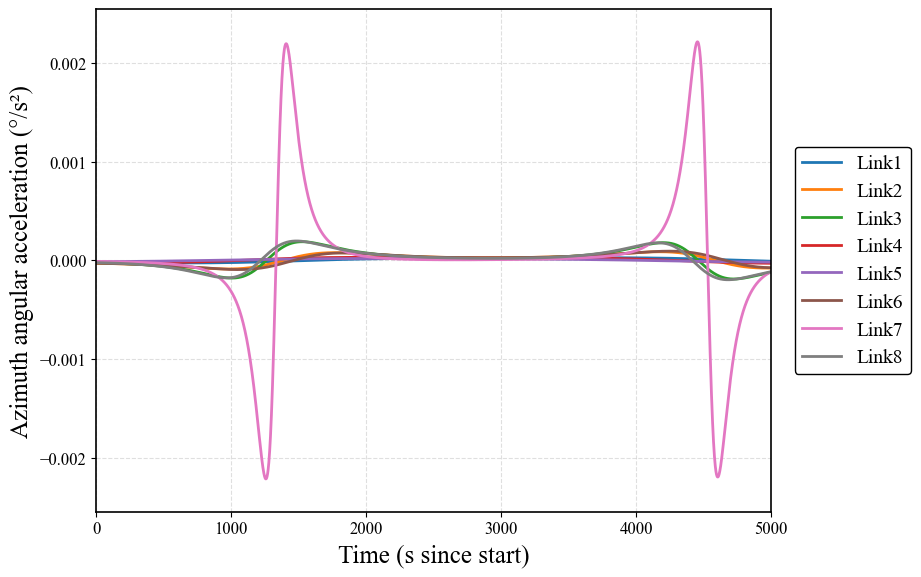

In [13]:
# === PLOT ONLY: acceleration (no ±0.15, no broken axis, stable labels) ===
import matplotlib as mpl, matplotlib.pyplot as plt, numpy as np

MAX_T_SECONDS   = 5000
LEFT_PAD_RATIO  = 1.15
MIN_SPAN_MARGIN = 1e-6

rc = {"font.family":"Times New Roman","font.size":14,"axes.labelsize":18,
      "axes.titlesize":18,"xtick.labelsize":12,"ytick.labelsize":12,"axes.linewidth":1.2}
with mpl.rc_context(rc):
    fig, ax = plt.subplots(figsize=(10, 6))

    MAX_POINTS_PER_LINE = 20000
    def maybe_downsample(df):
        n=len(df);
        return df if n<=MAX_POINTS_PER_LINE else df.iloc[::int(np.ceil(n/MAX_POINTS_PER_LINE))].copy()

    y_max_abs = 0.0
    for item in ordered_series:                # ✅ 与上图一致
        if "accel_name" not in item: continue
        df = item["df"]
        if MAX_T_SECONDS is not None: df = df[df["t_seconds"] <= MAX_T_SECONDS]
        if df.empty: continue
        df = maybe_downsample(df)
        vals = df[item["accel_name"]].to_numpy()
        if vals.size: y_max_abs = max(y_max_abs, float(np.nanmax(np.abs(vals))))
        ax.plot(df["t_seconds"], vals, linewidth=2.0, label=item["link_id"])   # ✅ 固定 label

    ax.set_xlabel("Time (s since basicSa)")
    ax.set_ylabel("Azimuth angular acceleration (°/s²)")
    ax.grid(True, which="major", linestyle="--", alpha=0.4)
    if MAX_T_SECONDS is not None: ax.set_xlim(0, MAX_T_SECONDS)

    yspan = max(y_max_abs*LEFT_PAD_RATIO, MIN_SPAN_MARGIN)
    ax.set_ylim(-yspan, yspan)

    plt.tight_layout(rect=[0,0,0.82,1])
    leg = ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5),
                    frameon=True, framealpha=1.0, ncol=1)
    leg.get_frame().set_edgecolor("black")
    plt.show()


然后这里，就是俯仰角的

1.俯仰角速度

2.俯仰角加速度

In [19]:

ROOT = r"E:\研究生\data\stk\Eleslewrate"
all_files = list_txt_files(ROOT)
print(f"发现 {len(all_files)} 个数据文件。")
if not all_files:
    raise FileNotFoundError(f"目录下未发现 .txt 文件: {ROOT}")

# ============== 并发读取（提速） ==============
MAX_WORKERS = min(8, (os.cpu_count() or 4))  # 适当限制线程数，避免过载
series_list: List[Dict[str, Any]] = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    fut2path = {ex.submit(load_one_file, fp): fp for fp in all_files}
    for fut in as_completed(fut2path):
        fp = fut2path[fut]
        try:
            series_list.append(fut.result())
        except Exception as e:
            print(f"[跳过] 解析失败: {fp}  —— {e}")

print(f"成功解析 {len(series_list)} 个文件。")

# ============== 绘图（单图叠加） ==============
# 可选：下采样，避免超大数据导致绘图卡顿
MAX_POINTS_PER_LINE = 20000  # 你可以按需要调整
def maybe_downsample(df: pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    if n <= MAX_POINTS_PER_LINE:
        return df
    step = int(np.ceil(n / MAX_POINTS_PER_LINE))
    return df.iloc[::step].copy()



发现 8 个数据文件。
成功解析 8 个文件。


Link1: qf-01-17-qf-02-15
Link2: qf-01-17-qf-02-16
Link3: qf-01-17-qf-02-17
Link4: qf-01-17-qf-02-18
Link5: qf-01-17-qf-02-19
Link6: qf-01-17-qf-03-15
Link7: qf-01-17-qf-03-16
Link8: qf-01-17-qf-03-17


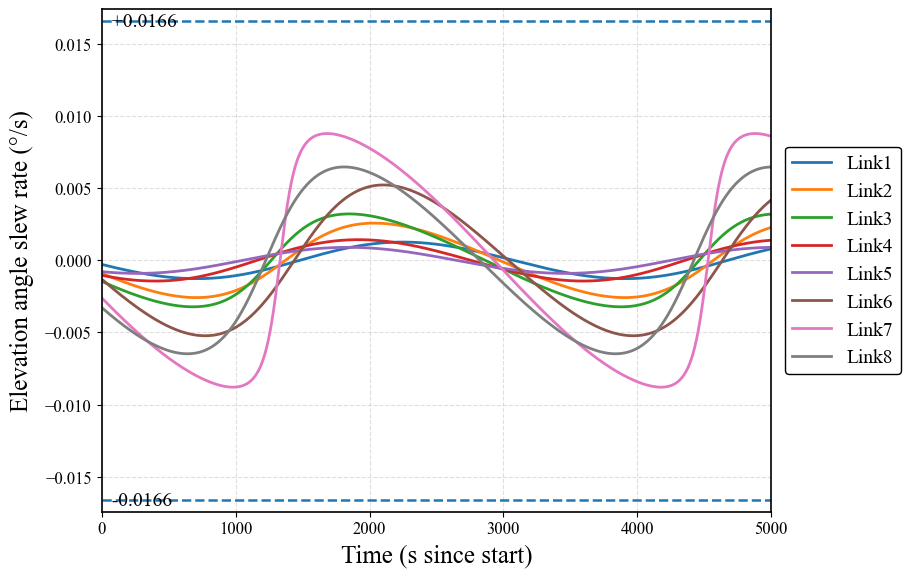

In [20]:
# === ORDER + PLOTTING ONLY (uses existing series_list) ===
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


# 仅绘制的时间范围（秒） & 阈值（上下对称）
MAX_T_SECONDS = 5000
THRESH_Y = 0.0166  # °/s：Azimuth angle slew rate 界限（±THRESH_Y 都要画）


# —— 固定顺序（你已有 sort_key / ordered_series）——
ordered_series = sorted(series_list, key=sort_key)

# 给每条曲线绑定一个固定的 link_id，后面所有图都用它
def pair_to_slug(p1, p2):
    p1, p2 = normalize_pair(p1, p2)
    return f"{p1.lower().replace('_','-')}-{p2.lower().replace('_','-')}"

for i, item in enumerate(ordered_series, 1):
    item["link_id"] = f"Link{i}"

# 打印一次映射，之后不再变化
for item in ordered_series:
    p1, p2 = item["pair"]
    print(f'{item["link_id"]}: {pair_to_slug(p1, p2)}')

# —— 绘图（右侧图例 + 上下两条阈值线 ±THRESH_Y）——
rc = {
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
}
with mpl.rc_context(rc):
    fig, ax = plt.subplots(figsize=(10, 6))

    MAX_POINTS_PER_LINE = 50000
    def maybe_downsample(df):
        n = len(df)
        if n <= MAX_POINTS_PER_LINE:
            return df
        step = int(np.ceil(n / MAX_POINTS_PER_LINE))
        return df.iloc[::step].copy()

    y_max, y_min = 0.0, 0.0
    for idx, item in enumerate(ordered_series, 1):
        df = item["df"]
        if MAX_T_SECONDS is not None:
            df = df[df["t_seconds"] <= MAX_T_SECONDS]
        if df.empty:
            continue
        df = maybe_downsample(df)
        yname = item["value_name"]
        y_max = max(y_max, float(np.nanmax(df[yname].values)))
        y_min = min(y_min, float(np.nanmin(df[yname].values)))
        ax.plot(df["t_seconds"], df[yname], linewidth=2.0, label=f"Link{idx}")

    ax.set_xlabel("Time (s since basicSa)")
    ax.set_ylabel("Elevation angle slew rate (°/s)", labelpad=8)
    ax.grid(True, which="major", linestyle="--", alpha=0.4)

    # 轴范围（y 轴对称围绕 0，覆盖数据与阈值；x 轴限 0~MAX_T_SECONDS）
    span = max(abs(y_max), abs(y_min), THRESH_Y) * 1.05
    ax.set_ylim(-span, span)
    if MAX_T_SECONDS is not None:
        ax.set_xlim(0, MAX_T_SECONDS)

    # 画上下两条阈值线，并在当前 xlim 下标注
    for yline in (+THRESH_Y, -THRESH_Y):
        ax.axhline(yline, linestyle="--", linewidth=1.8)
    x0, _ = ax.get_xlim()




    ax.text(x0,  THRESH_Y, f"  +{THRESH_Y:.4f}", va="center", ha="left")
    ax.text(x0, -THRESH_Y, f"  -{THRESH_Y:.4f}", va="center", ha="left")

    # 图例放到右侧外部
    plt.tight_layout(rect=[0, 0, 0.82, 1])  # 右侧留白
    leg = ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        frameon=True,
        framealpha=1.0,
        ncol=1,
    )
    leg.get_frame().set_edgecolor("black")

    plt.show()


In [21]:
# === 一阶差分：由角速度(°/s) -> 角加速度(°/s²) ===
import numpy as np

for item in series_list:
    df = item["df"]
    v = df[item["value_name"]].to_numpy()   # 角速度
    t = df["t_seconds"].to_numpy()          # 秒

    if len(v) < 2:
        df["accel"] = np.array([np.nan] * len(v))
        item["accel_name"] = "accel"
        continue

    dv = np.diff(v)
    dt = np.diff(t)
    # 避免极端情况下 Δt 为 0
    dt[dt == 0] = np.finfo(float).eps

    acc = dv / dt                            # 一阶差分
    acc = np.insert(acc, 0, acc[0])          # 与原长度对齐（首个用前向差分值）

    df["accel"] = acc
    item["accel_name"] = "accel"


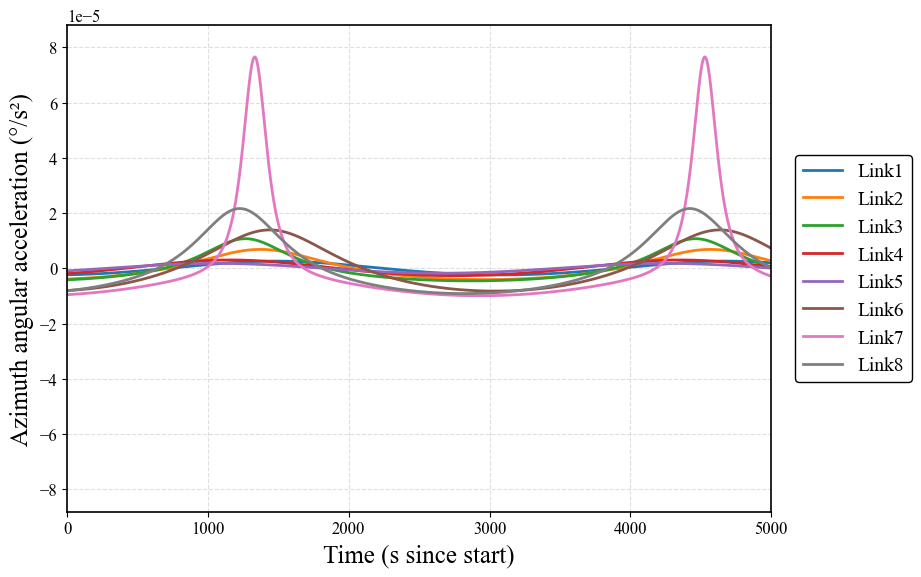

In [58]:
# === PLOT ONLY: acceleration (no ±0.15, no broken axis, stable labels) ===
import matplotlib as mpl, matplotlib.pyplot as plt, numpy as np

MAX_T_SECONDS   = 5000
LEFT_PAD_RATIO  = 1.15
MIN_SPAN_MARGIN = 1e-6

rc = {"font.family":"Times New Roman","font.size":14,"axes.labelsize":18,
      "axes.titlesize":18,"xtick.labelsize":12,"ytick.labelsize":12,"axes.linewidth":1.2}
with mpl.rc_context(rc):
    fig, ax = plt.subplots(figsize=(10, 6))

    MAX_POINTS_PER_LINE = 20000
    def maybe_downsample(df):
        n=len(df);
        return df if n<=MAX_POINTS_PER_LINE else df.iloc[::int(np.ceil(n/MAX_POINTS_PER_LINE))].copy()

    y_max_abs = 0.0
    for item in ordered_series:                # ✅ 与上图一致
        if "accel_name" not in item: continue
        df = item["df"]
        if MAX_T_SECONDS is not None: df = df[df["t_seconds"] <= MAX_T_SECONDS]
        if df.empty: continue
        df = maybe_downsample(df)
        vals = df[item["accel_name"]].to_numpy()
        if vals.size: y_max_abs = max(y_max_abs, float(np.nanmax(np.abs(vals))))
        ax.plot(df["t_seconds"], vals, linewidth=2.0, label=item["link_id"])   # ✅ 固定 label

    ax.set_xlabel("Time (s since basicSa)")
    ax.set_ylabel("Azimuth angular acceleration (°/s²)")
    ax.grid(True, which="major", linestyle="--", alpha=0.4)
    if MAX_T_SECONDS is not None: ax.set_xlim(0, MAX_T_SECONDS)

    yspan = max(y_max_abs*LEFT_PAD_RATIO, MIN_SPAN_MARGIN)
    ax.set_ylim(-yspan, yspan)

    plt.tight_layout(rect=[0,0,0.82,1])
    leg = ax.legend(loc="center left", bbox_to_anchor=(1.02,0.5),
                    frameon=True, framealpha=1.0, ncol=1)
    leg.get_frame().set_edgecolor("black")
    plt.show()


C:\Users\yfh\AppData\Local\Temp\ipykernel_39804\456403367.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.74, 1])


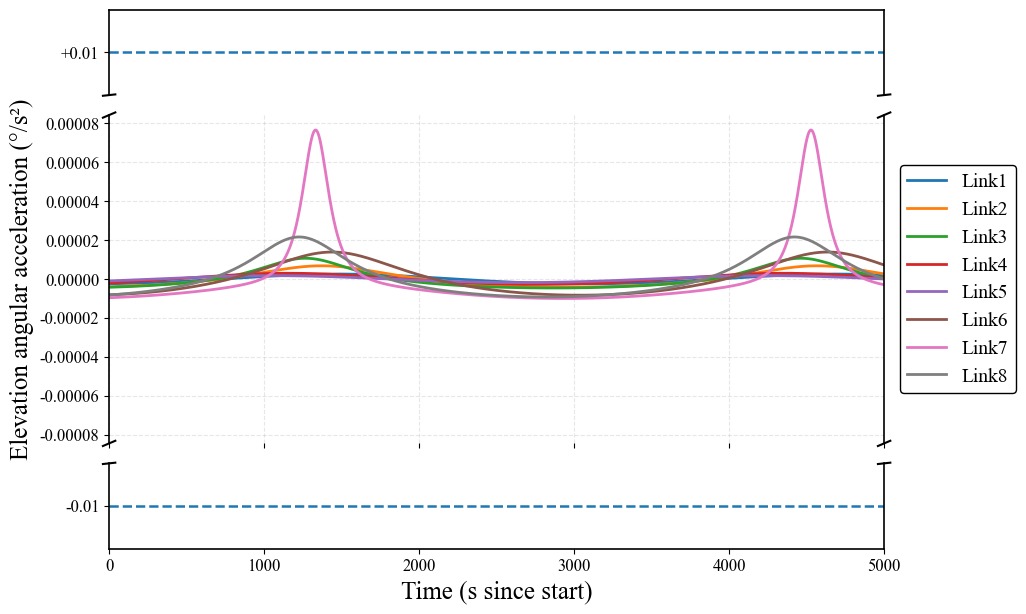

In [22]:
# === plot angular acceleration with a clean broken Y-axis (±0.01) & non-scientific y-ticks ===
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# —— 参数（按需改）——
MAX_T_SECONDS  = 5000       # x 轴时间窗口
THRESH_ACCEL   = 0.01       # °/s²：角加速度上下限（±THRESH_ACCEL）
LEFT_PAD_RATIO = 1.10       # 中轴在数据较小时的留白比例
MIN_SPAN_MID   = 1e-6       # 中轴最小半幅，避免零跨度

rc = {
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
}

with mpl.rc_context(rc):
    fig = plt.figure(figsize=(10, 7))
    gs  = fig.add_gridspec(nrows=3, ncols=1,
                           height_ratios=[1.3, 5.0, 1.3],
                           hspace=0.12)

    # 先建中轴，再让上下轴 sharex → 只在底部显示横坐标
    ax_mid = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_mid)
    ax_bot = fig.add_subplot(gs[2, 0], sharex=ax_mid)

    MAX_POINTS_PER_LINE = 20000
    def maybe_downsample(df):
        n = len(df)
        if n <= MAX_POINTS_PER_LINE:
            return df
        step = int(np.ceil(n / MAX_POINTS_PER_LINE))
        return df.iloc[::step].copy()

    # 用你已固定顺序/编号的 ordered_series；若没有则回退 series_list
    data_src = locals().get("ordered_series", series_list)

    # —— 仅在中轴画曲线（完全按数据自适应）——
    y_max_abs = 0.0
    for idx, item in enumerate(data_src, 1):
        if "accel_name" not in item:
            continue
        df = item["df"]
        if MAX_T_SECONDS is not None:
            df = df[df["t_seconds"] <= MAX_T_SECONDS]
        if df.empty:
            continue
        df = maybe_downsample(df)

        acc = df[item["accel_name"]].to_numpy()
        y_max_abs = max(y_max_abs, float(np.nanmax(np.abs(acc))))
        label = item.get("link_id", f"Link{idx}")
        ax_mid.plot(df["t_seconds"], acc, linewidth=2.0, label=label)

    # 样式
    ax_mid.grid(True, which="major", linestyle="--", alpha=0.3)
    ax_top.grid(False); ax_bot.grid(False)
    ax_mid.set_ylabel("Elevation angular acceleration (°/s²)")
    ax_bot.set_xlabel("Time (s since basicSa)")
    if MAX_T_SECONDS is not None:
        ax_mid.set_xlim(0, MAX_T_SECONDS)

    # —— 中轴范围：只按数据自适应（不受阈值影响），并关闭科学计数法 ——
    yspan = max(y_max_abs * LEFT_PAD_RATIO, MIN_SPAN_MID)
    ax_mid.set_ylim(-yspan, yspan)
    ax_mid.ticklabel_format(style="plain", axis="y", useOffset=False, useMathText=False)
    ax_mid.yaxis.set_major_formatter(FormatStrFormatter('%.5f'))  # 小数显示位数可改

    # —— 上/下小窗：围绕 ±阈值的窄窗口，仅显示“阈值”这一刻度 ——
    # margin 自适应：至少覆盖 3×中轴半幅；但不超过阈值的 25%，且不少于阈值的 5%
    THRESH_MARGIN = float(np.clip(3*yspan, 0.05*THRESH_ACCEL, 0.25*THRESH_ACCEL))
    ax_top.set_ylim( THRESH_ACCEL - THRESH_MARGIN,  THRESH_ACCEL + THRESH_MARGIN)
    ax_bot.set_ylim(-THRESH_ACCEL - THRESH_MARGIN, -THRESH_ACCEL + THRESH_MARGIN)
    ax_top.set_yticks([ THRESH_ACCEL]); ax_top.set_yticklabels([f"+{THRESH_ACCEL:.2f}"])
    ax_bot.set_yticks([-THRESH_ACCEL]); ax_bot.set_yticklabels([f"-{THRESH_ACCEL:.2f}"])

    # 阈值虚线（只在上下小轴）
    ax_top.axhline( THRESH_ACCEL, linestyle="--", linewidth=1.8, zorder=0)
    ax_bot.axhline(-THRESH_ACCEL, linestyle="--", linewidth=1.8, zorder=0)

    # —— 断轴处理：隐藏相邻脊，并仅在底部显示横坐标 ——
    ax_top.spines["bottom"].set_visible(False)
    ax_mid.spines["top"].set_visible(False)
    ax_mid.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)
    ax_top.tick_params(labelbottom=False, bottom=False)
    ax_mid.tick_params(labelbottom=False)

    # 断轴小斜线
    d = 0.008; kw = dict(color="k", clip_on=False)
    # 顶↔中
    ax_top.plot((-d,+d),(-d,+d), transform=ax_top.transAxes, **kw)
    ax_top.plot((1-d,1+d),(-d,+d), transform=ax_top.transAxes, **kw)
    ax_mid.plot((-d,+d),(1-d,1+d), transform=ax_mid.transAxes, **kw)
    ax_mid.plot((1-d,1+d),(1-d,1+d), transform=ax_mid.transAxes, **kw)
    # 中↔底
    ax_mid.plot((-d,+d),(-d,+d),   transform=ax_mid.transAxes, **kw)
    ax_mid.plot((1-d,1+d),(-d,+d), transform=ax_mid.transAxes, **kw)
    ax_bot.plot((-d,+d),(1-d,1+d), transform=ax_bot.transAxes, **kw)
    ax_bot.plot((1-d,1+d),(1-d,1+d), transform=ax_bot.transAxes, **kw)

    # 右侧外部图例
    # —— 右侧外部图例（锚在 ax_mid 外侧）——
    handles, labels = ax_mid.get_legend_handles_labels()

    # 先为右侧图例留更宽的边距（0.74 可按需要再调小/大）
    plt.tight_layout(rect=[0, 0, 0.74, 1])

    # 把图例锚在中轴坐标系外侧（x=1.02）——一定在轴外
    leg = ax_mid.legend(handles, labels,
                        loc="center left",
                        bbox_to_anchor=(1.02, 0.5),   # 轴外 2% 处
                        borderaxespad=0.0,
                        frameon=True, framealpha=1.0, ncol=1)
    leg.get_frame().set_edgecolor("black")


    plt.show()
